# Healthcare Analytics Project 
## Hospital Operations, Patient Risk and Business Recommendation Analysis

### Business Scenario
A hospital chain wants to understand patient admissions, readmissions, treatment cost, billing, pharmacy usage, lab results and follow-up behavior. The management team wants clear answers:

1. Which patient groups are high risk?
2. Which departments and hospitals have higher readmission?
3. What are the main cost drivers?
4. Where are data quality problems affecting business decisions?
5. What actions can reduce readmissions and improve hospital performance?

### Project Lifecycle Covered
1. Data audit
2. Data understanding
3. Data cleaning table by table
4. Missing values check and business-based handling
5. Data type correction
6. Outlier checking and handling
7. Feature engineering
8. Univariate analysis
9. Bivariate analysis
10. Multivariate analysis
11. Final insights and business recommendations

## 0. Import Libraries and Set Display Options

We use only beginner-friendly Python libraries:
- `pandas` for data handling
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for charts



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# pd.set_option('display.max_columns', 100)
# pd.set_option('display.width', 120)
# pd.set_option('display.max_rows', 100)

DATA_PATH = "C:/Users/shrih/Downloads/data_raw/data_raw"

## 1. Load All Raw Tables

In a real hospital project, data will not come from one Excel file. It usually comes from many systems:
- Patient registration system
- Admission system
- Doctor/department master data
- Treatment system
- Billing system
- Pharmacy system
- Lab system
- Follow-up system

Here we load all tables separately and then audit them.

In [7]:
DATA_PATH + 'billing_claims_raw.csv'

'C:/Users/shrih/Downloads/data_raw/data_rawbilling_claims_raw.csv'

In [9]:
'C:/Users/shrih/Downloads/data_raw/data_rawbilling_claims_raw.csv'

'C:/Users/shrih/Downloads/data_raw/data_rawbilling_claims_raw.csv'

In [10]:
hospitals_raw = pd.read_csv(os.path.join(DATA_PATH, 'hospitals.csv'))
departments_raw = pd.read_csv(os.path.join(DATA_PATH, 'departments.csv'))
doctors_raw = pd.read_csv(os.path.join(DATA_PATH, 'doctors.csv'))
patients_raw = pd.read_csv(os.path.join(DATA_PATH, 'patients_raw.csv'))
admissions_raw = pd.read_csv(os.path.join(DATA_PATH, 'admissions_raw.csv'))
treatments_raw = pd.read_csv(os.path.join(DATA_PATH, 'treatments_raw.csv'))
billing_raw = pd.read_csv(os.path.join(DATA_PATH, 'billing_claims_raw.csv'))
pharmacy_raw = pd.read_csv(os.path.join(DATA_PATH, 'pharmacy_orders_raw.csv'))
lab_raw = pd.read_csv(os.path.join(DATA_PATH, 'lab_results_raw.csv'))
followups_raw = pd.read_csv(os.path.join(DATA_PATH, 'followups_raw.csv'))


raw_tables = {
    'hospitals': hospitals_raw,
    'departments': departments_raw,
    'doctors': doctors_raw,
    'patients': patients_raw,
    'admissions': admissions_raw,
    'treatments': treatments_raw,
    'billing': billing_raw,
    'pharmacy': pharmacy_raw,
    'lab_results': lab_raw,
    'followups': followups_raw
}

for table_name, table in raw_tables.items():
    print(table_name, table.shape)

hospitals (8, 6)
departments (12, 3)
doctors (260, 7)
patients (12090, 10)
admissions (30130, 12)
treatments (90160, 7)
billing (30080, 10)
pharmacy (70090, 8)
lab_results (60000, 7)
followups (30000, 7)


## 2. Data Audit

Data audit means checking the raw condition of every table before cleaning.

We check:
- Number of rows and columns
- Duplicate rows
- Missing values
- Data types
- Unique IDs

This step is important because we should not clean data blindly. First, we must understand the problem.

In [11]:
doctors_raw.isna().sum()

doctor_id           0
doctor_name         0
department_id       0
specialization      0
hospital_id         0
experience_years    0
doctor_grade        0
dtype: int64

In [12]:
def audit_table(df, table_name, id_column=None):
    print('=' * 80)
    print('TABLE:', table_name)
    print('=' * 80)
    print('Rows and Columns:', df.shape)
    print('Duplicate Rows:', df.duplicated().sum())

    if id_column is not None and id_column in df.columns:
        print('Unique IDs:', df[id_column].nunique())
        print('Duplicate IDs:', df[id_column].duplicated().sum())
        print('Missing IDs:', df[id_column].isna().sum())

    print('Missing Values:')
    display(df.isna().sum().to_frame('missing_count'))

    print('Data Types:')
    display(df.dtypes.to_frame('data_type'))

    print('Sample Records:')
    display(df.head())



In [13]:
# Run audit on important tables
audit_table(patients_raw, 'patients', 'patient_id')

audit_table(admissions_raw, 'admissions', 'admission_id')

audit_table(treatments_raw, 'treatments', 'treatment_id')

audit_table(billing_raw, 'billing', 'bill_id')

TABLE: patients
Rows and Columns: (12090, 10)
Duplicate Rows: 0
Unique IDs: 12090
Duplicate IDs: 0
Missing IDs: 0
Missing Values:


,missing_count
patient_id,0
patient_code,0
patient_name,0
age,211
gender,0
city,170
primary_chronic_condition,3249
insurance_plan,0
income_segment,0
registration_date,0


Data Types:


,data_type
patient_id,int64
patient_code,object
patient_name,object
age,float64
gender,object
city,object
primary_chronic_condition,object
insurance_plan,object
income_segment,object
registration_date,object


Sample Records:


...

,missing_count
bill_id,0
admission_id,0
patient_id,0
payer_type,0
gross_amount,120
discount_amount,0
insurance_paid,0
patient_paid,0
claim_status,0
bill_date,0


Data Types:


,data_type
bill_id,int64
admission_id,int64
patient_id,int64
payer_type,object
gross_amount,float64
discount_amount,float64
insurance_paid,float64
patient_paid,float64
claim_status,object
bill_date,object


Sample Records:


,bill_id,admission_id,patient_id,payer_type,gross_amount,discount_amount,insurance_paid,patient_paid,claim_status,bill_date
0,1,1,3415,Premium Insurance,19940.46,1785.84,15939.06,2215.56,Paid,2024-03-10
1,2,2,3610,Basic Insurance,19034.64,558.14,13981.49,4495.01,Partial,2023-05-19
2,3,3,7584,Self Pay,20965.03,2413.86,18595.28,0.00,Rejected,2025-06-16
3,4,4,4459,Corporate Insurance,16637.20,1938.84,13657.64,1040.72,Rejected,2025-10-15
4,5,5,5508,Government Scheme,77727.52,2213.24,35959.21,39555.07,Paid,2024-05-07


### Data Audit Summary Table

This summary gives a quick management-style overview of data quality.

In [14]:
# raw_tables

In [16]:
audit_summary = []

for name, df in raw_tables.items():
    audit_summary.append({
        'table_name': name,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'duplicate_rows': df.duplicated().sum(),
        'total_missing_values': df.isna().sum().sum(),
        'missing_percentage': df.isnull().mean().mean() * 100
    })

audit_summary_df = pd.DataFrame(audit_summary)
display(audit_summary_df)

audit_summary_df.to_csv("C:/Users/shrih/Downloads/data_raw/data_raw/data_audit_summary.csv", index=False)

,table_name,rows,columns,duplicate_rows,total_missing_values,missing_percentage
0,hospitals,8,6,0,0,0.000000
1,departments,12,3,0,0,0.000000
2,doctors,260,7,0,0,0.000000
3,patients,12090,10,0,3630,3.002481
4,admissions,30130,12,130,394,0.108972
5,treatments,90160,7,160,300,0.047535
6,billing,30080,10,80,120,0.039894
7,pharmacy,70090,8,90,150,0.026751
8,lab_results,60000,7,0,120,0.028571
9,followups,30000,7,0,0,0.000000


## 3. Data Understanding

Before cleaning, students should understand what every table represents.

### Main Business Meaning
- `patients`: Who the patient is
- `admissions`: When and why the patient was admitted
- `treatments`: What treatments were given during admission
- `billing`: How much amount was billed and paid
- `pharmacy`: Medicines ordered during admission
- `lab_results`: Lab test outcomes
- `followups`: Whether post-discharge follow-up happened
- `doctors`, `departments`, `hospitals`: Master data used for analysis

### Important Business Grain
Grain means one row represents what?
- One row in patients = one patient
- One row in admissions = one hospital admission
- One row in treatments = one treatment event
- One row in billing = one billing claim
- One row in pharmacy = one medicine order line

This is important before merging tables.

In [17]:
for name, df in raw_tables.items():
    print('TABLE:', name)
    print(df.columns.tolist())

TABLE: hospitals
['hospital_id', 'hospital_name', 'city', 'ownership_type', 'bed_capacity', 'launch_year']
TABLE: departments
['department_id', 'department_name', 'care_complexity']
TABLE: doctors
['doctor_id', 'doctor_name', 'department_id', 'specialization', 'hospital_id', 'experience_years', 'doctor_grade']
TABLE: patients
['patient_id', 'patient_code', 'patient_name', 'age', 'gender', 'city', 'primary_chronic_condition', 'insurance_plan', 'income_segment', 'registration_date']
TABLE: admissions
['admission_id', 'patient_id', 'hospital_id', 'department_id', 'primary_doctor_id', 'admission_date', 'discharge_date', 'admission_type', 'diagnosis', 'severity_level', 'discharge_status', 'readmitted_30_days']
TABLE: treatments
['treatment_id', 'admission_id', 'doctor_id', 'treatment_type', 'treatment_cost', 'treatment_date', 'treatment_status']
TABLE: billing
['bill_id', 'admission_id', 'patient_id', 'payer_type', 'gross_amount', 'discount_amount', 'insurance_paid', 'patient_paid', 'claim_

# 4. Data Cleaning Table by Table

We clean each table separately. This is better than merging raw tables directly.

Rule for students:
> First clean individual tables, then merge.

If we merge dirty tables, errors multiply.

## 4.1 Clean Patients Table

Business problems in patient data may include:
- Age missing or unrealistic
- Gender entered in different formats
- City missing
- Chronic condition missing
- Registration date stored as text

### Business-based missing value handling
For age, we should not simply use the overall mean. A better approach is to fill missing age using the median age of patients with the same chronic condition. If that is not available, then use the overall median.

In [18]:
patients_clean = patients_raw.copy()

# Remove exact duplicate rows
patients_clean = patients_clean.drop_duplicates()

# Clean text columns by removing spaces
text_columns = ['patient_code', 'patient_name', 'gender', 'city', 'primary_chronic_condition', 'insurance_plan', 'income_segment']
for col in text_columns:
    patients_clean[col] = patients_clean[col].astype(str).str.strip()

In [19]:
patients_clean['gender'].unique()

array(['Female', 'Male', 'Other', 'MALE', 'male', 'M', 'Unknown',
       'female', 'F', 'Femle'], dtype=object)

In [20]:
# Clean gender values
patients_clean['gender_clean'] = patients_clean['gender'].str.lower()
patients_clean['gender_clean'] = patients_clean['gender_clean'].replace({
    'm': 'Male',
    'male': 'Male',
    'f': 'Female',
    'female': 'Female',
    'femle' : 'Female',
    'nan': 'Unknown',
    '': 'Unknown'
})


In [21]:
# cross check 
patients_clean['gender_clean'].unique()

array(['Female', 'Male', 'other', 'unknown'], dtype=object)

In [22]:
# let me check the city data
patients_clean['city'].unique()

array(['Hyderabad', 'Ahmedabad', 'nan', 'Pune', 'Bengaluru', 'Vijayawada',
       'Mumbai', 'Warangal', 'Jaipur', 'Delhi', 'Nagpur', 'Lucknow',
       'Kolkata', 'Indore', 'Chennai'], dtype=object)

In [23]:
patients_clean['primary_chronic_condition'].unique()

array(['Heart Failure', 'Hypertension', 'Asthma', 'Diabetes', 'nan',
       'COPD', 'CKD', 'Cancer'], dtype=object)

In [24]:
# Clean city
patients_clean['city_clean'] = patients_clean['city'].replace({'nan': 'Unknown', '': 'Unknown'})

# Clean chronic condition. This column contains disease names, not Yes/No.
patients_clean['chronic_condition_clean'] = patients_clean['primary_chronic_condition'].str.title()
patients_clean['chronic_condition_clean'] = patients_clean['chronic_condition_clean'].replace({
    'Nan': 'Unknown',
    '': 'Unknown',
    'None': 'Unknown',
    'Null': 'Unknown'
})

# Create chronic flag: 1 means condition available, 0 means unknown
patients_clean['chronic_flag'] = np.where(patients_clean['chronic_condition_clean'] == 'Unknown', 0, 1)
patients_clean.head()

,patient_id,patient_code,patient_name,age,gender,city,primary_chronic_condition,insurance_plan,income_segment,registration_date,gender_clean,city_clean,chronic_condition_clean,chronic_flag
0,1,P00001,Patient_BKOKF,46.0,Female,Hyderabad,Heart Failure,Premium Insurance,Low,2016-09-25,Female,Hyderabad,Heart Failure,1
1,2,P00002,Patient_KXPSW,58.0,Male,Hyderabad,Heart Failure,Basic Insurance,Low,2022-09-12,Male,Hyderabad,Heart Failure,1
2,3,P00003,Patient_TJAJT,51.0,Female,Ahmedabad,Hypertension,Government Scheme,Middle,2014-08-02,Female,Ahmedabad,Hypertension,1
3,4,P00004,Patient_WYKTO,25.0,Male,nan,Heart Failure,Self Pay,Middle,2017-03-23,Male,Unknown,Heart Failure,1
4,5,P00005,Patient_PFFLA,54.0,Male,nan,Asthma,Basic Insurance,Middle,2021-11-22,Male,Unknown,Asthma,1


In [25]:
patients_clean.loc[(patients_clean['age'] < 0) | (patients_clean['age'] > 100), 'age'] 

437      150.0
612      135.0
963       -3.0
1493     150.0
1525     119.0
1822     119.0
1929      -3.0
2226     150.0
2589     119.0
2705     150.0
2796     135.0
2980      -3.0
3073     119.0
3269     150.0
3334     150.0
3453     135.0
3806      -3.0
3943     150.0
3969     135.0
3997     119.0
4097     135.0
4158     135.0
4529     119.0
4746     119.0
4906     119.0
4924      -3.0
5014     119.0
5236     135.0
5540      -3.0
5547     150.0
5827      -3.0
5896      -3.0
5909     150.0
6042      -3.0
6152     119.0
6379     135.0
6395     150.0
6411     150.0
6695      -3.0
7039     150.0
7079     150.0
7155     150.0
7466     150.0
7528     135.0
7692     150.0
8026     135.0
8450     150.0
8607     119.0
8769     119.0
8796     150.0
8993     150.0
9270     119.0
9877     119.0
10175    150.0
10177    150.0
10437    135.0
10685    135.0
11470    119.0
11589     -3.0
11704    119.0
Name: age, dtype: float64

In [26]:
# Convert registration date
patients_clean['registration_date'] = pd.to_datetime(patients_clean['registration_date'], errors='coerce')

# Age cleaning
# Unrealistic ages are treated as missing because they can disturb analysis.
patients_clean.loc[(patients_clean['age'] < 0) | (patients_clean['age'] > 100), 'age'] = np.nan

# Fill missing age using median age for same chronic condition
patients_clean['age'] = patients_clean.groupby('chronic_condition_clean')['age'].transform(lambda x: x.fillna(x.median()))

In [27]:
# patients_clean['age'].isnull().sum()

In [28]:
# If still missing, fill with overall median age
patients_clean['age'] = patients_clean['age'].fillna(patients_clean['age'].median())

# Convert age to integer for clean reporting
patients_clean['age'] = patients_clean['age'].round().astype(int)

patients_clean[['patient_id', 'age', 'gender', 'gender_clean', 'city_clean', 'chronic_condition_clean', 'chronic_flag']].head()

,patient_id,age,gender,gender_clean,city_clean,chronic_condition_clean,chronic_flag
0,1,46,Female,Female,Hyderabad,Heart Failure,1
1,2,58,Male,Male,Hyderabad,Heart Failure,1
2,3,51,Female,Female,Ahmedabad,Hypertension,1
3,4,25,Male,Male,Unknown,Heart Failure,1
4,5,54,Male,Male,Unknown,Asthma,1


### Patient Cleaning Insight

- Age is handled using disease-group median because age patterns differ by disease.
- Chronic condition is preserved as a disease name, not converted into Yes/No blindly.
- `chronic_flag` is created only for analysis convenience.

### Business Recommendation
Hospitals should standardize patient registration forms using dropdowns for gender, city, insurance plan and chronic condition to reduce manual entry errors.

## 4.2 Clean Admissions Table

Admissions table is central to the project because most analysis happens at admission level.

Business problems:
- Admission and discharge dates may be stored as text
- Discharge date may be missing
- Discharge date can be earlier than admission date due to entry error
- Readmission values may have inconsistent labels

In [29]:
# 01/02/2025 ---01/03/2025--03/01/2025

In [31]:
#45 days

In [32]:
admissions_clean = admissions_raw.copy()
admissions_clean = admissions_clean.drop_duplicates()

# Convert dates
admissions_clean['admission_date'] = pd.to_datetime(admissions_clean['admission_date'], errors='coerce')
admissions_clean['discharge_date'] = pd.to_datetime(admissions_clean['discharge_date'], errors='coerce')

# Clean text columns
for col in ['admission_type', 'diagnosis', 'severity_level', 'discharge_status', 'readmitted_30_days']:
    admissions_clean[col] = admissions_clean[col].astype(str).str.strip()

# Standardize readmitted values
admissions_clean['readmitted_clean'] = admissions_clean['readmitted_30_days'].str.lower().replace({
    'yes': 'Yes', 
    'y': 'Yes', 'true': 'Yes', '1': 'Yes',
    'no': 'No', 'n': 'No', 'false': 'No', '0': 'No',
    'nan': 'Unknown', '': 'Unknown'
})

# Calculate length of stay
admissions_clean['length_of_stay'] = (admissions_clean['discharge_date'] - admissions_clean['admission_date']).dt.days
admissions_clean.head()

,admission_id,patient_id,hospital_id,department_id,primary_doctor_id,admission_date,discharge_date,admission_type,diagnosis,severity_level,discharge_status,readmitted_30_days,readmitted_clean,length_of_stay
0,1,3415,8,4,123,2024-03-10,2024-03-16,Emergency,Anemia,Critical,Home,Yes,Yes,6.0
1,2,3610,8,1,209,2023-05-19,2023-05-20,Planned,Arrhythmia,Moderate,Home,No,No,1.0
2,3,7584,8,3,190,2025-06-16,2025-06-18,Emergency,Joint Replacement,Moderate,Home,Yes,Yes,2.0
3,4,4459,2,3,176,2025-10-15,2025-10-16,Referral,Joint Replacement,Moderate,Home,No,No,1.0
4,5,5508,3,12,140,2024-05-07,2024-05-23,Planned,Multi Organ Dysfunction,Moderate,Home,No,No,16.0


In [33]:
admissions_clean[admissions_clean['length_of_stay'] < 0]

,admission_id,patient_id,hospital_id,department_id,primary_doctor_id,admission_date,discharge_date,admission_type,diagnosis,severity_level,discharge_status,readmitted_30_days,readmitted_clean,length_of_stay


In [34]:
# Negative LOS is not possible. Treat as missing.
admissions_clean.loc[admissions_clean['length_of_stay'] < 0, 'length_of_stay'] = np.nan

# Business-based LOS handling:
# Use median LOS for the same department and admission type.
admissions_clean['length_of_stay'] = admissions_clean.groupby(['department_id', 'admission_type'])['length_of_stay'].transform(
    lambda x: x.fillna(x.median())
)

# If still missing, use overall median LOS.
admissions_clean['length_of_stay'] = admissions_clean['length_of_stay'].fillna(admissions_clean['length_of_stay'].median())


# Avoid zero days. Same-day admission is counted as 1 day for occupancy/cost-per-day logic.
admissions_clean['length_of_stay'] = admissions_clean['length_of_stay'].clip(lower=1)
admissions_clean['length_of_stay'] = admissions_clean['length_of_stay'].round().astype(int)

admissions_clean[['admission_id', 'admission_date', 'discharge_date', 'admission_type', 'readmitted_clean', 'length_of_stay']].head()

,admission_id,admission_date,discharge_date,admission_type,readmitted_clean,length_of_stay
0,1,2024-03-10,2024-03-16,Emergency,Yes,6
1,2,2023-05-19,2023-05-20,Planned,No,1
2,3,2025-06-16,2025-06-18,Emergency,Yes,2
3,4,2025-10-15,2025-10-16,Referral,No,1
4,5,2024-05-07,2024-05-23,Planned,No,16


### Admission Cleaning Insight

- Length of stay is not filled using a random number.
- It is filled based on department and admission type because ICU emergency cases and planned dermatology cases cannot have the same stay pattern.

### Business Recommendation
Hospital systems should validate discharge date at entry time. A discharge date earlier than admission date should not be allowed.

## 4.3 Clean Treatments Table

Treatment cost is important for cost analysis. But cost data can have missing values and extreme outliers.

Business-based missing value handling:
- Treatment cost depends on treatment type and doctor/department practice.
- So we fill missing treatment cost using median cost of the same treatment type.

In [35]:
treatments_clean = treatments_raw.copy()
treatments_clean = treatments_clean.drop_duplicates()

# Convert date
treatments_clean['treatment_date'] = pd.to_datetime(treatments_clean['treatment_date'], errors='coerce')

# Clean text columns
for col in ['treatment_type', 'treatment_status']:
    treatments_clean[col] = treatments_clean[col].astype(str).str.strip().str.title()

# Negative treatment cost is not valid
treatments_clean.loc[treatments_clean['treatment_cost'] < 0, 'treatment_cost'] = np.nan

# Fill missing treatment cost using treatment type median
treatments_clean['treatment_cost'] = treatments_clean.groupby('treatment_type')['treatment_cost'].transform(
    lambda x: x.fillna(x.median())
)

# If still missing, fill with overall median
treatments_clean['treatment_cost'] = treatments_clean['treatment_cost'].fillna(treatments_clean['treatment_cost'].median())

treatments_clean[['treatment_id', 'admission_id', 'treatment_type', 'treatment_cost', 'treatment_status']].head()

,treatment_id,admission_id,treatment_type,treatment_cost,treatment_status
0,1,27337,Surgery,52636.30,Completed
1,2,982,Imaging,7478.12,Completed
2,3,17082,Chemotherapy,27451.58,Completed
3,4,4096,Lab Package,3379.43,Pending
4,5,26108,Icu Care,19993.51,Completed


## 4.4 Clean Billing Table

Billing data is sensitive because wrong cleaning can give wrong business conclusions.

Business checks:
- Gross amount should not be negative
- Patient paid + insurance paid + discount should be close to gross amount
- Claim status should be standardized

In [36]:
billing_clean = billing_raw.copy()
billing_clean = billing_clean.drop_duplicates()

billing_clean['bill_date'] = pd.to_datetime(billing_clean['bill_date'], errors='coerce')

for col in ['payer_type', 'claim_status']:
    billing_clean[col] = billing_clean[col].astype(str).str.strip().str.title()

amount_cols = ['gross_amount', 'discount_amount', 'insurance_paid', 'patient_paid']
for col in amount_cols:
    billing_clean.loc[billing_clean[col] < 0, col] = np.nan

# Business-based missing value handling:
# Fill amount columns by payer type median because different insurance plans have different payment patterns.
for col in amount_cols:
    billing_clean[col] = billing_clean.groupby('payer_type')[col].transform(lambda x: x.fillna(x.median()))
    billing_clean[col] = billing_clean[col].fillna(billing_clean[col].median())

# Create billing gap to check reconciliation issue
billing_clean['billing_reconciliation_gap'] = billing_clean['gross_amount'] - (
    billing_clean['discount_amount'] + billing_clean['insurance_paid'] + billing_clean['patient_paid']
)

billing_clean[['bill_id', 'admission_id', 'payer_type', 'gross_amount', 'insurance_paid', 'patient_paid', 'billing_reconciliation_gap']].head()

,bill_id,admission_id,payer_type,gross_amount,insurance_paid,patient_paid,billing_reconciliation_gap
0,1,1,Premium Insurance,19940.46,15939.06,2215.56,0.000000e+00
1,2,2,Basic Insurance,19034.64,13981.49,4495.01,0.000000e+00
2,3,3,Self Pay,20965.03,18595.28,0.00,-4.411000e+01
3,4,4,Corporate Insurance,16637.20,13657.64,1040.72,0.000000e+00
4,5,5,Government Scheme,77727.52,35959.21,39555.07,1.455192e-11


## 4.5 Clean Pharmacy, Lab and Follow-up Tables

These tables support deeper analysis:
- Pharmacy helps understand medicine cost
- Lab results help understand abnormal results
- Follow-up helps understand whether readmission is linked with missed follow-ups

In [37]:
pharmacy_clean = pharmacy_raw.copy().drop_duplicates()

# traking care of string columns
pharmacy_clean['medicine_name'] = pharmacy_clean['medicine_name'].astype(str).str.strip().str.title()
pharmacy_clean['pharmacy_type'] = pharmacy_clean['pharmacy_type'].astype(str).str.strip().str.title()

# handling the inconsistant data
pharmacy_clean.loc[pharmacy_clean['quantity'] < 0, 'quantity'] = np.nan
pharmacy_clean.loc[pharmacy_clean['unit_price'] < 0, 'unit_price'] = np.nan

# Filling the missing values in quantity column by the business logic using medicine_name
pharmacy_clean['quantity'] = pharmacy_clean.groupby('medicine_name')['quantity'].transform(lambda x: x.fillna(x.median()))

# Fillint the missing values in unitprice baced on the medicne type
pharmacy_clean['unit_price'] = pharmacy_clean.groupby('medicine_name')['unit_price'].transform(lambda x: x.fillna(x.median()))

pharmacy_clean['line_amount'] = pharmacy_clean['quantity'] * pharmacy_clean['unit_price']
pharmacy_clean.head()

,order_id,admission_id,patient_id,medicine_name,quantity,unit_price,line_amount,pharmacy_type
0,1,29377,7899,Insulin,15.0,57.66,864.90,Ip Pharmacy
1,2,25956,2404,Anticoagulant,1.0,33.52,33.52,Ip Pharmacy
2,3,18883,6450,Chemotherapy Drug,17.0,188.65,3207.05,Op Pharmacy
3,4,21967,10792,Metformin,3.0,37.73,113.19,Op Pharmacy
4,5,17705,4645,Amlodipine,20.0,95.68,1913.60,Op Pharmacy


In [38]:
lab_clean = lab_raw.copy().drop_duplicates()
lab_clean['test_date'] = pd.to_datetime(lab_clean['test_date'], errors='coerce')


# Standardizing the lebel in the string columns
lab_clean['test_name'] = lab_clean['test_name'].astype(str).str.strip().str.title()
lab_clean['result_flag'] = lab_clean['result_flag'].astype(str).str.strip().str.title()
lab_clean['result_flag'] = lab_clean['result_flag'].replace({'Nan': 'Unknown', '': 'Unknown'})
lab_clean.head()

,lab_id,admission_id,patient_id,test_name,test_value,test_date,result_flag
0,1,2133,11981,Crp,5.99,2023-01-01,Abnormal
1,2,5569,5064,Sodium,2.46,2023-01-01,Normal
2,3,17271,1824,Crp,2.84,2023-01-01,Abnormal
3,4,24486,9939,Hba1C,14.91,2023-01-01,Normal
4,5,21094,8920,Hemoglobin,11.46,2023-01-01,Abnormal


In [39]:
followups_clean = followups_raw.copy().drop_duplicates()

followups_clean['followup_due_date'] = pd.to_datetime(followups_clean['followup_due_date'], errors='coerce')

# Standardizing the lebel in the string columns
for col in ['followup_completed', 'followup_mode', 'followup_outcome']:
    followups_clean[col] = followups_clean[col].astype(str).str.strip().str.title()

followups_clean['followup_completed_clean'] = followups_clean['followup_completed'].replace({
    'Y': 'Yes', 'N': 'No', 'True': 'Yes', 'False': 'No', 'Nan': 'Unknown', '': 'Unknown'
})

print('Pharmacy:', pharmacy_clean.shape)
print('Lab:', lab_clean.shape)
print('Followups:', followups_clean.shape)

Pharmacy: (70000, 8)
Lab: (60000, 7)
Followups: (30000, 8)


## 5. Data Type Check and Correction

After cleaning, we check whether each important column has the correct data type.

In [40]:
clean_tables = {
    'patients_clean': patients_clean,
    'admissions_clean': admissions_clean,
    'treatments_clean': treatments_clean,
    'billing_clean': billing_clean,
    'pharmacy_clean': pharmacy_clean,
    'lab_clean': lab_clean,
    'followups_clean': followups_clean
}

for name, df in clean_tables.items():
    print('', name)
    display(df.dtypes.to_frame('data_type'))

 patients_clean


,data_type
patient_id,int64
patient_code,object
patient_name,object
age,int64
gender,object
city,object
primary_chronic_condition,object
insurance_plan,object
income_segment,object
registration_date,datetime64[ns]


 admissions_clean


,data_type
admission_id,int64
patient_id,int64
hospital_id,int64
department_id,int64
primary_doctor_id,int64
admission_date,datetime64[ns]
discharge_date,datetime64[ns]
admission_type,object
diagnosis,object
severity_level,object


 treatments_clean


...

,data_type
order_id,int64
admission_id,int64
patient_id,int64
medicine_name,object
quantity,float64
unit_price,float64
line_amount,float64
pharmacy_type,object


 lab_clean


,data_type
lab_id,int64
admission_id,int64
patient_id,int64
test_name,object
test_value,float64
test_date,datetime64[ns]
result_flag,object


 followups_clean


,data_type
followup_id,int64
admission_id,int64
patient_id,int64
followup_due_date,datetime64[ns]
followup_completed,object
followup_mode,object
followup_outcome,object
followup_completed_clean,object


## 6. Outlier Check and Handling

Outlier handling should not be automatic. We first identify outliers, then decide based on business logic.

Examples:
- A very high bill may be valid for ICU surgery.
- A very high age like 150 is invalid.
- Very high treatment cost may be a data error or may represent critical care.

For cost columns, instead of deleting all outliers, we cap extreme values using the IQR method. This is safer for student-level analytics.

In [41]:
# Creating the function gto cehck the outlier and to get lower and upper limits
def iqr_limits(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [42]:
def outlier_summary(df, column):
    lower, upper = iqr_limits(df[column])
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return {
        'column': column,
        'lower_limit': round(lower, 2),
        'upper_limit': round(upper, 2),
        'outlier_count': len(outliers),
        'outlier_percentage': round(len(outliers) / len(df) * 100, 2)
    }

In [46]:
outlier_report = pd.DataFrame([
    outlier_summary(treatments_clean, 'treatment_cost'),
    outlier_summary(billing_clean, 'gross_amount'),
    outlier_summary(pharmacy_clean, 'line_amount'),
    outlier_summary(admissions_clean, 'length_of_stay')
])

display(outlier_report)
outlier_report.to_csv("C:/Users/shrih/Downloads/data_raw/data_raw/outlier_report.csv", index=False)

,column,lower_limit,upper_limit,outlier_count,outlier_percentage
0,treatment_cost,-16849.72,34369.03,8553,9.50
1,gross_amount,-54947.40,128041.70,1144,3.81
2,line_amount,-1186.14,2745.11,4856,6.94
3,length_of_stay,-7.00,17.00,1376,4.59


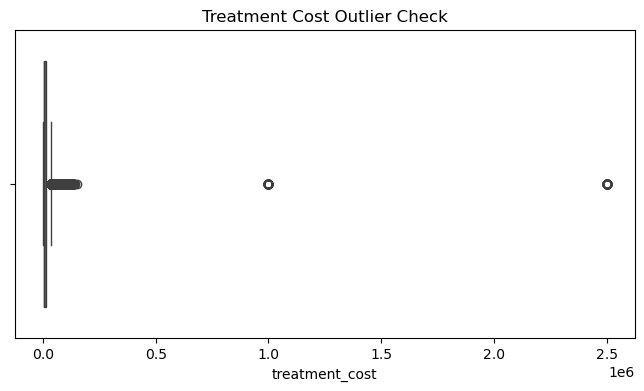

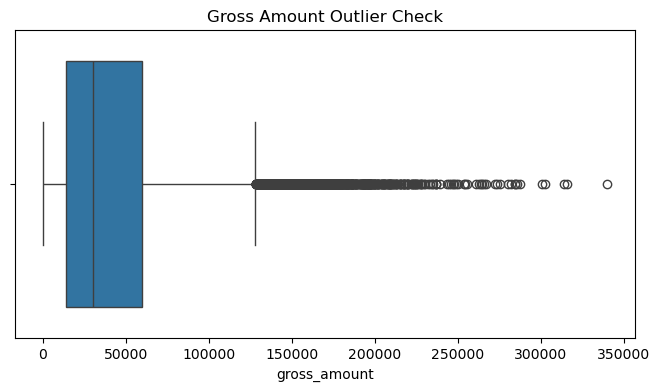

In [47]:
# Visual check for outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=treatments_clean['treatment_cost'])
plt.title('Treatment Cost Outlier Check')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=billing_clean['gross_amount'])
plt.title('Gross Amount Outlier Check')
plt.show()

In [48]:
# Cap extreme treatment cost and billing amount using IQR limits.
# We create new capped columns so original values are not lost.

for df, source_col, capped_col in [
    (treatments_clean, 'treatment_cost', 'treatment_cost_capped'),
    (billing_clean, 'gross_amount', 'gross_amount_capped'),
    (pharmacy_clean, 'line_amount', 'line_amount_capped')
]:
    # Body of the loop
    lower, upper = iqr_limits(df[source_col])
    df[capped_col] = df[source_col].clip(lower=lower, upper=upper)

print('Outlier capping completed. Original and capped columns are both available.')

Outlier capping completed. Original and capped columns are both available.


### Outlier Handling Insight

We did not delete high-cost records because high-cost patients are important for hospital cost optimization. Instead, we capped extreme values for stable analysis and preserved original columns for audit.

### Business Recommendation
Finance teams should review unusually high treatment and billing records separately instead of removing them from analysis.

## 7. Feature Engineering

Feature engineering means creating new useful columns from existing data.

For this healthcare project, we create:
- Age group
- Admission month
- Total treatment cost per admission
- Total pharmacy cost per admission
- Abnormal lab count per admission
- Follow-up completion flag
- Total cost per admission
- Cost per day
- Patient visit frequency
- Simple patient risk segment

In [49]:
# Age group
patients_clean['age_group'] = pd.cut(
    patients_clean['age'],
    bins=[0, 18, 30, 45, 60, 75, 120],
    labels=['0-18', '19-30', '31-45', '46-60', '61-75', '75+']
)
patients_clean.head()

,patient_id,patient_code,patient_name,age,gender,city,primary_chronic_condition,insurance_plan,income_segment,registration_date,gender_clean,city_clean,chronic_condition_clean,chronic_flag,age_group
0,1,P00001,Patient_BKOKF,46,Female,Hyderabad,Heart Failure,Premium Insurance,Low,2016-09-25,Female,Hyderabad,Heart Failure,1,46-60
1,2,P00002,Patient_KXPSW,58,Male,Hyderabad,Heart Failure,Basic Insurance,Low,2022-09-12,Male,Hyderabad,Heart Failure,1,46-60
2,3,P00003,Patient_TJAJT,51,Female,Ahmedabad,Hypertension,Government Scheme,Middle,2014-08-02,Female,Ahmedabad,Hypertension,1,46-60
3,4,P00004,Patient_WYKTO,25,Male,nan,Heart Failure,Self Pay,Middle,2017-03-23,Male,Unknown,Heart Failure,1,19-30
4,5,P00005,Patient_PFFLA,54,Male,nan,Asthma,Basic Insurance,Middle,2021-11-22,Male,Unknown,Asthma,1,46-60


In [50]:
# Admission month
admissions_clean['admission_month'] = admissions_clean['admission_date'].dt.to_period('M').astype(str)
admissions_clean.head()

,admission_id,patient_id,hospital_id,department_id,primary_doctor_id,admission_date,discharge_date,admission_type,diagnosis,severity_level,discharge_status,readmitted_30_days,readmitted_clean,length_of_stay,admission_month
0,1,3415,8,4,123,2024-03-10,2024-03-16,Emergency,Anemia,Critical,Home,Yes,Yes,6,2024-03
1,2,3610,8,1,209,2023-05-19,2023-05-20,Planned,Arrhythmia,Moderate,Home,No,No,1,2023-05
2,3,7584,8,3,190,2025-06-16,2025-06-18,Emergency,Joint Replacement,Moderate,Home,Yes,Yes,2,2025-06
3,4,4459,2,3,176,2025-10-15,2025-10-16,Referral,Joint Replacement,Moderate,Home,No,No,1,2025-10
4,5,5508,3,12,140,2024-05-07,2024-05-23,Planned,Multi Organ Dysfunction,Moderate,Home,No,No,16,2024-05


In [51]:
# Aggregate treatment cost per admission
treatment_summary = treatments_clean.groupby('admission_id').agg(
    total_treatment_cost=('treatment_cost_capped', 'sum'),
    treatment_count=('treatment_id', 'count')
).reset_index()
treatment_summary.head()

,admission_id,total_treatment_cost,treatment_count
0,1,13633.72,3
1,2,16345.82,2
2,3,7095.49,2
3,4,7229.08,2
4,5,75709.09,3


In [52]:
# Aggregate billing per admission
billing_summary = billing_clean.groupby('admission_id').agg(
    total_bill=('gross_amount_capped', 'sum'),
    total_patient_paid=('patient_paid', 'sum'),
    total_insurance_paid=('insurance_paid', 'sum')
).reset_index()
billing_summary

,admission_id,total_bill,total_patient_paid,total_insurance_paid
0,1,19940.46,2215.56,15939.06
1,2,19034.64,4495.01,13981.49
2,3,20965.03,0.00,18595.28
3,4,16637.20,1040.72,13657.64
4,5,77727.52,39555.07,35959.21
...,...,...,...,...
29995,882059,9200.73,3863.45,4620.51
29996,883180,19138.29,18581.30,0.00
29997,885404,19518.03,2106.11,14544.49
29998,893376,14632.63,13532.01,0.00


In [53]:
# Aggregate pharmacy cost per admission
pharmacy_summary = pharmacy_clean.groupby('admission_id').agg(
    total_pharmacy_cost=('line_amount_capped', 'sum'),
    medicine_count=('medicine_name', 'count')
).reset_index()
pharmacy_summary

,admission_id,total_pharmacy_cost,medicine_count
0,1,1437.450,2
1,2,1173.510,1
2,3,3801.190,4
3,4,5845.615,5
4,6,3218.550,2
...,...,...,...
27101,29995,3636.375,2
27102,29996,3420.670,3
27103,29997,4898.880,5
27104,29998,753.920,4


In [54]:
# Lab abnormal count per admission
lab_clean['is_abnormal'] = np.where(lab_clean['result_flag'] == 'Abnormal', 1, 0)


lab_summary = lab_clean.groupby('admission_id').agg(
    total_lab_tests=('lab_id', 'count'),
    abnormal_lab_count=('is_abnormal', 'sum')
).reset_index()
lab_summary

,admission_id,total_lab_tests,abnormal_lab_count
0,1,1,1
1,2,1,0
2,3,2,1
3,4,1,0
4,5,1,0
...,...,...,...
25861,29996,4,0
25862,29997,2,0
25863,29998,3,0
25864,29999,2,1


In [55]:
# Follow-up completion per admission
followups_clean['followup_done_flag'] = np.where(followups_clean['followup_completed_clean'] == 'Yes', 1, 0)

followup_summary = followups_clean.groupby('admission_id').agg(
    followup_done=('followup_done_flag', 'sum')
).reset_index()

print('Feature summary tables created.')
followup_summary

Feature summary tables created.


,admission_id,followup_done
0,1,1
1,2,1
2,3,1
3,4,0
4,5,1
...,...,...
29995,29996,1
29996,29997,1
29997,29998,1
29998,29999,1


## 8. Build Final Analytical Dataset

Now we merge cleaned tables to create one admission-level analytical dataset.

Important teaching point:
> The final dataset grain is one row per admission.

In [56]:
analysis_df = admissions_clean.merge(
    patients_clean[['patient_id', 'age', 'age_group', 'gender_clean', 'city_clean', 'chronic_condition_clean', 'chronic_flag', 'insurance_plan', 'income_segment']],
    on='patient_id',
    how='left'
)

analysis_df = analysis_df.merge(hospitals_raw, on='hospital_id', how='left')
analysis_df = analysis_df.merge(departments_raw, on='department_id', how='left')
analysis_df = analysis_df.merge(doctors_raw[['doctor_id', 'doctor_name', 'doctor_grade', 'experience_years']],
                                left_on='primary_doctor_id', right_on='doctor_id', how='left')
analysis_df = analysis_df.merge(treatment_summary, on='admission_id', how='left')
analysis_df = analysis_df.merge(billing_summary, on='admission_id', how='left')
analysis_df = analysis_df.merge(pharmacy_summary, on='admission_id', how='left')
analysis_df = analysis_df.merge(lab_summary, on='admission_id', how='left')
analysis_df = analysis_df.merge(followup_summary, on='admission_id', how='left')

analysis_df.head()

,admission_id,patient_id,hospital_id,department_id,primary_doctor_id,admission_date,discharge_date,admission_type,diagnosis,severity_level,...,total_treatment_cost,treatment_count,total_bill,total_patient_paid,total_insurance_paid,total_pharmacy_cost,medicine_count,total_lab_tests,abnormal_lab_count,followup_done
0,1,3415,8,4,123,2024-03-10,2024-03-16,Emergency,Anemia,Critical,...,13633.72,3.0,19940.46,2215.56,15939.06,1437.450,2.0,1.0,1.0,1
1,2,3610,8,1,209,2023-05-19,2023-05-20,Planned,Arrhythmia,Moderate,...,16345.82,2.0,19034.64,4495.01,13981.49,1173.510,1.0,1.0,0.0,1
2,3,7584,8,3,190,2025-06-16,2025-06-18,Emergency,Joint Replacement,Moderate,...,7095.49,2.0,20965.03,0.00,18595.28,3801.190,4.0,2.0,1.0,1
3,4,4459,2,3,176,2025-10-15,2025-10-16,Referral,Joint Replacement,Moderate,...,7229.08,2.0,16637.20,1040.72,13657.64,5845.615,5.0,1.0,0.0,0
4,5,5508,3,12,140,2024-05-07,2024-05-23,Planned,Multi Organ Dysfunction,Moderate,...,75709.09,3.0,77727.52,39555.07,35959.21,NaN,NaN,1.0,0.0,1


In [57]:
# Fill missing aggregated values with 0 because no linked record means no recorded treatment/pharmacy/lab/follow-up.
fill_zero_cols = [
    'total_treatment_cost', 'treatment_count', 'total_bill', 'total_patient_paid', 'total_insurance_paid',
    'total_pharmacy_cost', 'medicine_count', 'total_lab_tests', 'abnormal_lab_count', 'followup_done'
]
analysis_df[fill_zero_cols] = analysis_df[fill_zero_cols].fillna(0)

In [58]:
# Day 2

In [59]:
# Total operational cost proxy
analysis_df['total_cost_proxy'] = analysis_df['total_treatment_cost'] + analysis_df['total_pharmacy_cost']
analysis_df['cost_per_day'] = analysis_df['total_cost_proxy'] / analysis_df['length_of_stay']
analysis_df.head()

,admission_id,patient_id,hospital_id,department_id,primary_doctor_id,admission_date,discharge_date,admission_type,diagnosis,severity_level,...,total_bill,total_patient_paid,total_insurance_paid,total_pharmacy_cost,medicine_count,total_lab_tests,abnormal_lab_count,followup_done,total_cost_proxy,cost_per_day
0,1,3415,8,4,123,2024-03-10,2024-03-16,Emergency,Anemia,Critical,...,19940.46,2215.56,15939.06,1437.450,2.0,1.0,1.0,1,15071.170,2511.861667
1,2,3610,8,1,209,2023-05-19,2023-05-20,Planned,Arrhythmia,Moderate,...,19034.64,4495.01,13981.49,1173.510,1.0,1.0,0.0,1,17519.330,17519.330000
2,3,7584,8,3,190,2025-06-16,2025-06-18,Emergency,Joint Replacement,Moderate,...,20965.03,0.00,18595.28,3801.190,4.0,2.0,1.0,1,10896.680,5448.340000
3,4,4459,2,3,176,2025-10-15,2025-10-16,Referral,Joint Replacement,Moderate,...,16637.20,1040.72,13657.64,5845.615,5.0,1.0,0.0,0,13074.695,13074.695000
4,5,5508,3,12,140,2024-05-07,2024-05-23,Planned,Multi Organ Dysfunction,Moderate,...,77727.52,39555.07,35959.21,0.000,0.0,1.0,0.0,1,75709.090,4731.818125


In [60]:
# Readmission flag
analysis_df['readmitted_flag'] = np.where(analysis_df['readmitted_clean'] == 'Yes', 1, 0)

analysis_df.head()

,admission_id,patient_id,hospital_id,department_id,primary_doctor_id,admission_date,discharge_date,admission_type,diagnosis,severity_level,...,total_patient_paid,total_insurance_paid,total_pharmacy_cost,medicine_count,total_lab_tests,abnormal_lab_count,followup_done,total_cost_proxy,cost_per_day,readmitted_flag
0,1,3415,8,4,123,2024-03-10,2024-03-16,Emergency,Anemia,Critical,...,2215.56,15939.06,1437.450,2.0,1.0,1.0,1,15071.170,2511.861667,1
1,2,3610,8,1,209,2023-05-19,2023-05-20,Planned,Arrhythmia,Moderate,...,4495.01,13981.49,1173.510,1.0,1.0,0.0,1,17519.330,17519.330000,0
2,3,7584,8,3,190,2025-06-16,2025-06-18,Emergency,Joint Replacement,Moderate,...,0.00,18595.28,3801.190,4.0,2.0,1.0,1,10896.680,5448.340000,1
3,4,4459,2,3,176,2025-10-15,2025-10-16,Referral,Joint Replacement,Moderate,...,1040.72,13657.64,5845.615,5.0,1.0,0.0,0,13074.695,13074.695000,0
4,5,5508,3,12,140,2024-05-07,2024-05-23,Planned,Multi Organ Dysfunction,Moderate,...,39555.07,35959.21,0.000,0.0,1.0,0.0,1,75709.090,4731.818125,0


In [62]:
print('Final analytical dataset shape:', analysis_df.shape)
print('One row represents one admission.')
analysis_df.to_csv( "C:/Users/shrih/Downloads/data_raw/data_raw/final_admission_level_dataset.csv", index=False)

Final analytical dataset shape: (30000, 47)
One row represents one admission.


## 9. More Feature Engineering: Patient Visit Frequency and Risk Segment

Instead of directly jumping to machine learning, we create understandable risk features.

Risk logic for beginners:
- Older age increases risk
- Chronic condition increases risk
- Previous/frequent visits increase risk
- Abnormal lab results increase risk
- Missed follow-up increases risk

In [63]:
# Visit frequency per patient
patient_visit_summary = analysis_df.groupby('patient_id').agg(
    patient_total_admissions=('admission_id', 'count'),
    patient_total_readmissions=('readmitted_flag', 'sum'),
    patient_total_cost=('total_cost_proxy', 'sum')
).reset_index()
patient_visit_summary

,patient_id,patient_total_admissions,patient_total_readmissions,patient_total_cost
0,1,5,3,102436.61000
1,2,4,1,158693.76875
2,3,2,2,47841.98500
3,4,2,2,57002.57875
4,5,3,1,146476.60250
...,...,...,...,...
10961,999284,1,1,11375.03000
10962,999421,1,1,39474.84875
10963,999437,1,1,5036.55000
10964,999599,1,1,7060.55000


In [64]:
analysis_df = analysis_df.merge(patient_visit_summary, on='patient_id', how='left')

# Simple risk score. This is explainable, not a machine learning model.
analysis_df['risk_score'] = 0
analysis_df['risk_score'] += np.where(analysis_df['age'] >= 60, 2, 0)
analysis_df['risk_score'] += np.where(analysis_df['chronic_flag'] == 1, 2, 0)
analysis_df['risk_score'] += np.where(analysis_df['patient_total_admissions'] >= 3, 2, 0)
analysis_df['risk_score'] += np.where(analysis_df['abnormal_lab_count'] >= 2, 1, 0)
analysis_df['risk_score'] += np.where(analysis_df['followup_done'] == 0, 1, 0)

analysis_df['risk_segment'] = pd.cut(
    analysis_df['risk_score'],
    bins=[-1, 2, 5, 10],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

analysis_df[['patient_id', 'age', 'chronic_flag', 'patient_total_admissions', 'abnormal_lab_count', 'followup_done', 'risk_score', 'risk_segment']].head()

,patient_id,age,chronic_flag,patient_total_admissions,abnormal_lab_count,followup_done,risk_score,risk_segment
0,3415,69.0,1.0,5,1.0,1,6,High Risk
1,3610,49.0,1.0,3,0.0,1,4,Medium Risk
2,7584,52.0,1.0,4,1.0,1,4,Medium Risk
3,4459,24.0,1.0,5,0.0,0,5,Medium Risk
4,5508,37.0,1.0,5,0.0,1,4,Medium Risk


### Feature Engineering Insight

This risk score is explainable to hospital managers. It does not require advanced ML, but it helps prioritize patients.

### Business Recommendation
Start with an explainable risk score before building advanced ML models. Hospital teams are more likely to trust simple and transparent scoring methods.

# 10. Data Analysis

Now we perform:
1. Univariate analysis: one variable at a time
2. Bivariate analysis: relation between two variables
3. Multivariate analysis: multiple variables together

For every analysis, students should write:
- Observation
- Insight
- Business recommendation

## 10.1 Univariate Analysis

We analyze one column at a time to understand distribution.

In [65]:
analysis_df['admission_type'].head()

0    Emergency
1      Planned
2    Emergency
3     Referral
4      Planned
Name: admission_type, dtype: object

In [66]:
# Admission type distribution
admission_type_counts = analysis_df['admission_type'].value_counts()
display(admission_type_counts)

admission_type
Emergency    13061
Planned       8545
Referral      5353
Follow-up     3041
Name: count, dtype: int64

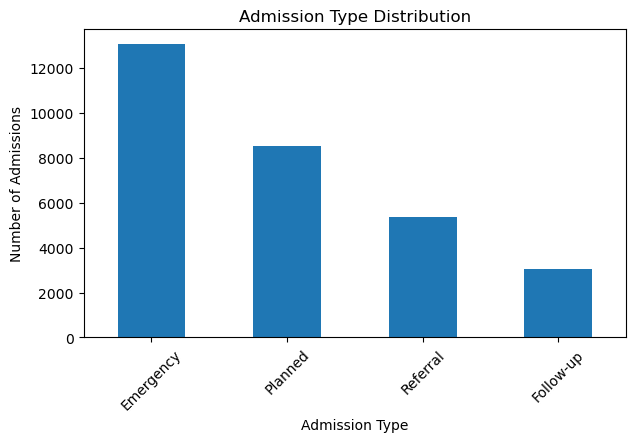

In [67]:


plt.figure(figsize=(7, 4))
admission_type_counts.plot(kind='bar')
plt.title('Admission Type Distribution')
plt.xlabel('Admission Type')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
plt.show()

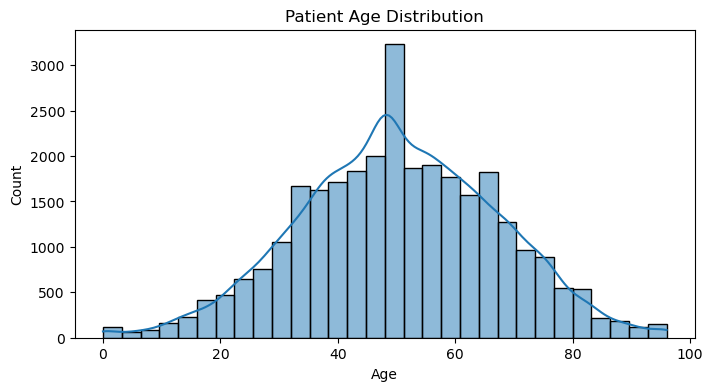

count    29925.000000
mean        50.268237
std         16.952145
min          0.000000
25%         39.000000
50%         50.000000
75%         62.000000
max         96.000000
Name: age, dtype: float64

In [68]:
# Age distribution
plt.figure(figsize=(8, 4))
sns.histplot(analysis_df['age'], bins=30, kde=True)
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

analysis_df['age'].describe()

In [69]:
# Risk segment distribution
risk_counts = analysis_df['risk_segment'].value_counts()
display(risk_counts)


risk_segment
Medium Risk    17645
High Risk       6382
Low Risk        5973
Name: count, dtype: int64

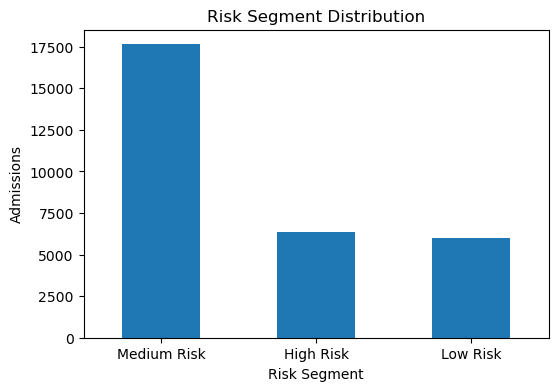

In [70]:
plt.figure(figsize=(6, 4))
risk_counts.plot(kind='bar')
plt.title('Risk Segment Distribution')
plt.xlabel('Risk Segment')
plt.ylabel('Admissions')
plt.xticks(rotation=0)
plt.show()

### Univariate Insights and Recommendations

Example writing format:

**Insight 1:** If emergency admissions are high, hospital resources may be under pressure.

**Recommendation:** Keep emergency staffing and bed allocation flexible during high-demand periods.

**Insight 2:** If many patients fall in older age groups, readmission and follow-up care become more important.

**Recommendation:** Create age-based discharge and follow-up protocols.

## 10.2 Bivariate Analysis

Bivariate analysis checks how one variable changes with another.

In [71]:
# Readmission rate by department
readmission_by_department = analysis_df.groupby('department_name').agg(
    admissions=('admission_id', 'count'),
    readmissions=('readmitted_flag', 'sum')
).reset_index()
readmission_by_department

,department_name,admissions,readmissions
0,Cardiology,3589,1997
1,Emergency,4340,1886
2,Endocrinology,1320,590
3,Gastroenterology,1620,714
4,General Medicine,4260,1878
5,ICU,3309,1837
6,Nephrology,1626,902
7,Neurology,1956,862
8,Oncology,1376,767
9,Orthopedics,2743,1151


In [72]:
readmission_by_department['readmission_rate'] = readmission_by_department['readmissions'] / readmission_by_department['admissions']
readmission_by_department = readmission_by_department.sort_values('readmission_rate', ascending=False)

display(readmission_by_department.head(10))

,department_name,admissions,readmissions,readmission_rate
8,Oncology,1376,767,0.557413
0,Cardiology,3589,1997,0.556422
5,ICU,3309,1837,0.555153
6,Nephrology,1626,902,0.554736
11,Pulmonology,2469,1366,0.553260
2,Endocrinology,1320,590,0.446970
4,General Medicine,4260,1878,0.440845
3,Gastroenterology,1620,714,0.440741
7,Neurology,1956,862,0.440695
1,Emergency,4340,1886,0.434562


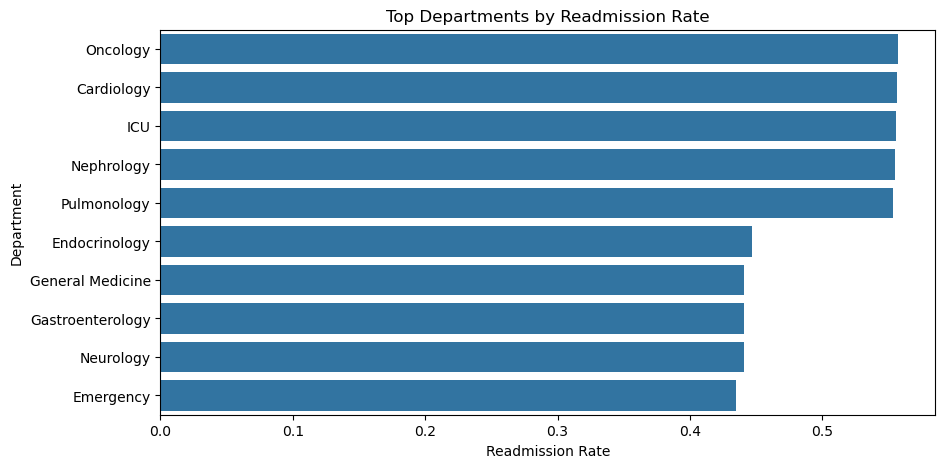

In [73]:
plt.figure(figsize=(10, 5))
sns.barplot(data=readmission_by_department.head(10), x='readmission_rate', y='department_name')
plt.title('Top Departments by Readmission Rate')
plt.xlabel('Readmission Rate')
plt.ylabel('Department')
plt.show()

,department_name,avg_cost,median_cost,admissions
8,Oncology,44020.648957,39509.81875,1376
5,ICU,39508.072799,35628.04000,3309
10,Pediatrics,31365.026264,26437.09500,1392
6,Nephrology,31030.756232,25591.68000,1626
4,General Medicine,30859.974602,25272.58750,4260
9,Orthopedics,30826.314947,25800.08000,2743
0,Cardiology,30814.195929,24418.31000,3589
1,Emergency,30748.280789,25272.60500,4340
7,Neurology,30740.142319,25499.64000,1956
11,Pulmonology,30583.689030,24103.58000,2469


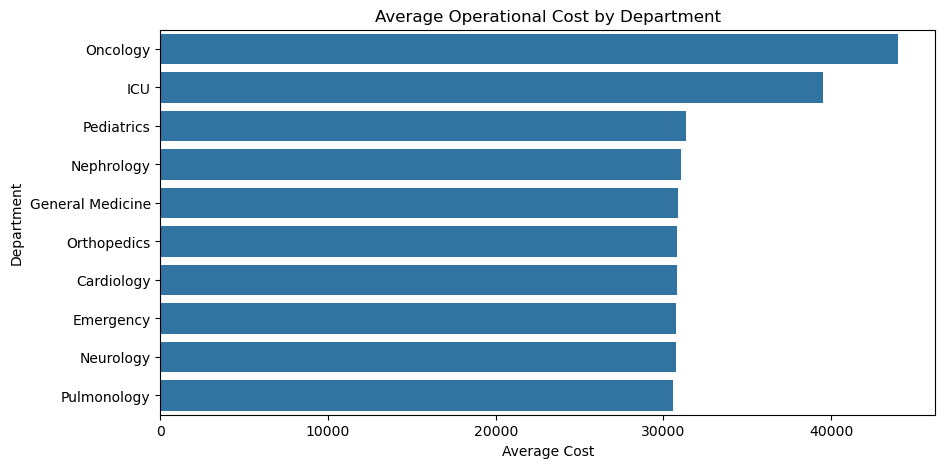

In [74]:
# Cost by department
cost_by_department = analysis_df.groupby('department_name').agg(
    avg_cost=('total_cost_proxy', 'mean'),
    median_cost=('total_cost_proxy', 'median'),
    admissions=('admission_id', 'count')
).reset_index().sort_values('avg_cost', ascending=False)

display(cost_by_department.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=cost_by_department.head(10), x='avg_cost', y='department_name')
plt.title('Average Operational Cost by Department')
plt.xlabel('Average Cost')
plt.ylabel('Department')
plt.show()

In [75]:
# Follow-up vs readmission
followup_readmission = analysis_df.groupby('followup_done').agg(
    admissions=('admission_id', 'count'),
    readmissions=('readmitted_flag', 'sum')
).reset_index()
followup_readmission

,followup_done,admissions,readmissions
0,0,11408,5575
1,1,18592,8966


In [76]:
followup_readmission['readmission_rate'] = followup_readmission['readmissions'] / followup_readmission['admissions']

display(followup_readmission)

,followup_done,admissions,readmissions,readmission_rate
0,0,11408,5575,0.488692
1,1,18592,8966,0.482250


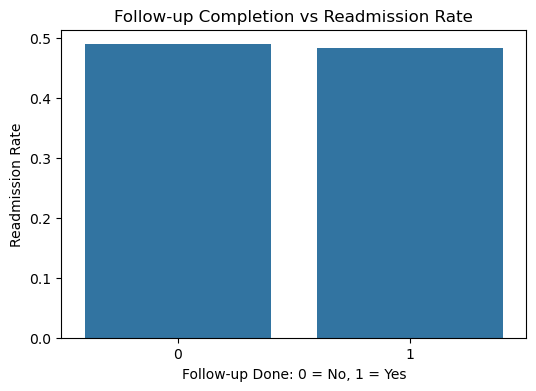

In [77]:
plt.figure(figsize=(6, 4))
sns.barplot(data=followup_readmission, x='followup_done', y='readmission_rate')
plt.title('Follow-up Completion vs Readmission Rate')
plt.xlabel('Follow-up Done: 0 = No, 1 = Yes')
plt.ylabel('Readmission Rate')
plt.show()

### Bivariate Insights and Recommendations

**Insight 1:** Departments with high readmission need deeper discharge quality review.

**Recommendation:** Create department-wise readmission review meetings every month.

**Insight 2:** If patients without follow-up show higher readmission, follow-up is not just operational activity, it is a risk-control strategy.

**Recommendation:** Create automatic follow-up reminders for high-risk patients within 7 days after discharge.

## 10.3 Multivariate Analysis

Multivariate analysis checks multiple factors together.

Examples:
- Readmission by department and risk segment
- Cost by severity level and admission type
- Correlation between numeric variables

In [78]:
# Readmission by department and risk segment
pivot_readmission = pd.pivot_table(
    analysis_df,
    values='readmitted_flag',
    index='department_name',
    columns='risk_segment',
    aggfunc='mean'
)

display(pivot_readmission)

C:\Users\shrih\AppData\Local\Temp\ipykernel_25728\2757695402.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_readmission = pd.pivot_table(


risk_segment,Low Risk,Medium Risk,High Risk
department_name,,,
Cardiology,0.446304,0.546770,0.680451
Emergency,0.321510,0.419545,0.583878
Endocrinology,0.300847,0.452055,0.555160
Gastroenterology,0.339934,0.429887,0.561765
General Medicine,0.325749,0.435219,0.559013
ICU,0.474790,0.539453,0.689024
Nephrology,0.450794,0.536170,0.690027
Neurology,0.362998,0.418811,0.584577
Oncology,0.424603,0.567237,0.640523


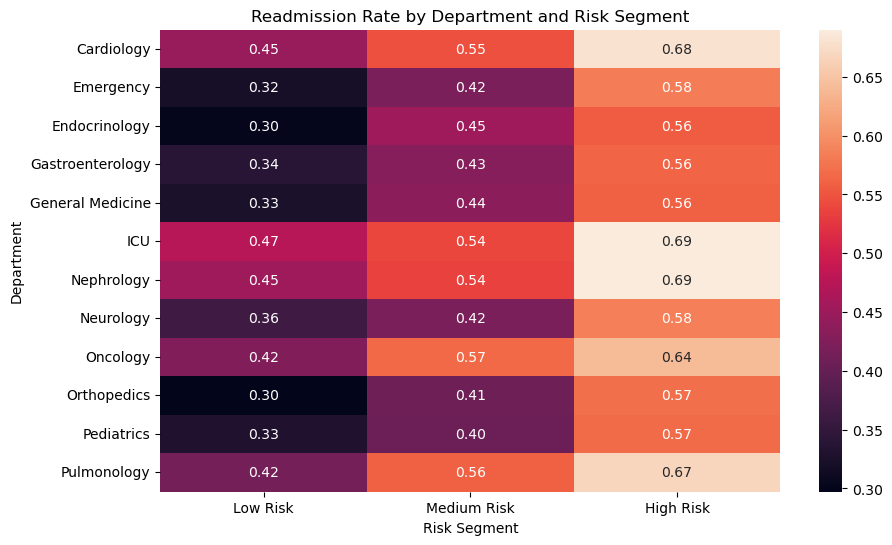

In [79]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_readmission, annot=True, fmt='.2f')
plt.title('Readmission Rate by Department and Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Department')
plt.show()

In [80]:
# Cost by severity and admission type
cost_pivot = pd.pivot_table(
    analysis_df,
    values='total_cost_proxy',
    index='severity_level',
    columns='admission_type',
    aggfunc='mean'
)

display(cost_pivot)

admission_type,Emergency,Follow-up,Planned,Referral
severity_level,,,,
Critical,33710.412084,32600.244793,31939.633719,32656.901479
High,32080.132244,32095.969153,33564.360472,32936.124459
Low,32279.797598,32410.360515,31130.167946,33349.552763
Moderate,32241.433223,32509.996683,32446.892537,31323.387493


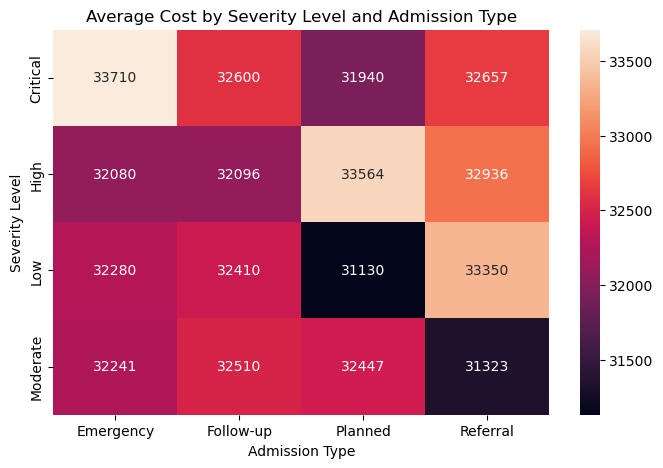

In [81]:
plt.figure(figsize=(8, 5))
sns.heatmap(cost_pivot, annot=True, fmt='.0f')
plt.title('Average Cost by Severity Level and Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Severity Level')
plt.show()

In [82]:
# Correlation among numeric variables
numeric_cols = [
    'age', 'length_of_stay', 'total_treatment_cost', 'total_pharmacy_cost',
    'total_cost_proxy', 'cost_per_day', 'abnormal_lab_count', 'patient_total_admissions',
    'risk_score', 'readmitted_flag'
]

corr_matrix = analysis_df[numeric_cols].corr()
corr_matrix

,age,length_of_stay,total_treatment_cost,total_pharmacy_cost,total_cost_proxy,cost_per_day,abnormal_lab_count,patient_total_admissions,risk_score,readmitted_flag
age,1.000000,-0.000453,-0.004586,0.005815,-0.004169,-0.007846,0.005503,0.134049,0.443879,0.194817
length_of_stay,-0.000453,1.000000,0.069552,0.003267,0.069633,-0.407241,-0.006978,0.000924,0.000511,0.039155
total_treatment_cost,-0.004586,0.069552,1.000000,-0.004666,0.997549,0.547425,-0.005930,0.000220,0.002385,-0.000339
total_pharmacy_cost,0.005815,0.003267,-0.004666,1.000000,0.065320,0.039451,-0.006438,0.001454,0.010440,0.006848
total_cost_proxy,-0.004169,0.069633,0.997549,0.065320,1.000000,0.549022,-0.006368,0.000322,0.003111,0.000141
cost_per_day,-0.007846,-0.407241,0.547425,0.039451,0.549022,1.000000,0.009257,0.003661,0.002924,-0.022631
abnormal_lab_count,0.005503,-0.006978,-0.005930,-0.006438,-0.006368,0.009257,1.000000,0.005224,0.165017,-0.003116
patient_total_admissions,0.134049,0.000924,0.000220,0.001454,0.000322,0.003661,0.005224,1.000000,0.532241,0.049823
risk_score,0.443879,0.000511,0.002385,0.010440,0.003111,0.002924,0.165017,0.532241,1.000000,0.160851
readmitted_flag,0.194817,0.039155,-0.000339,0.006848,0.000141,-0.022631,-0.003116,0.049823,0.160851,1.000000


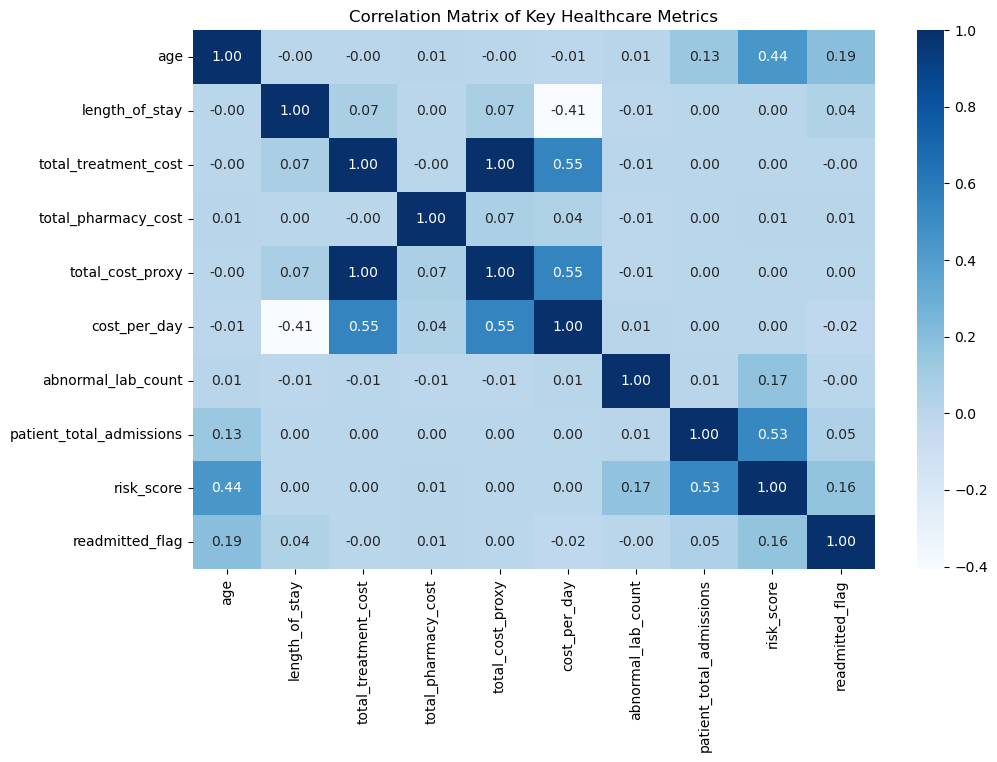

In [83]:
plt.figure(figsize=(11, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix of Key Healthcare Metrics')
plt.show()

### Multivariate Insights and Recommendations

**Insight 1:** High-risk segments within specific departments can show stronger readmission patterns than department alone.

**Recommendation:** Do not create one common discharge policy for all patients. Create department + risk-level based discharge protocols.

**Insight 2:** Critical severity and emergency admissions may show higher average cost.

**Recommendation:** Create emergency cost monitoring and resource planning for critical cases.

## 11. Executive Summary Tables

These tables are useful for final presentation or dashboard preparation.

In [84]:
# Hospital level summary
hospital_summary = analysis_df.groupby(['hospital_id', 'hospital_name', 'city']).agg(
    total_admissions=('admission_id', 'count'),
    unique_patients=('patient_id', 'nunique'),
    readmission_rate=('readmitted_flag', 'mean'),
    avg_los=('length_of_stay', 'mean'),
    avg_cost=('total_cost_proxy', 'mean'),
    total_cost=('total_cost_proxy', 'sum')
).reset_index()

hospital_summary = hospital_summary.sort_values('total_admissions', ascending=False)
display(hospital_summary)

,hospital_id,hospital_name,city,total_admissions,unique_patients,readmission_rate,avg_los,avg_cost,total_cost
0,1,MedNova Hospital - Hyderabad,Hyderabad,5258,4250,0.492393,6.042412,32436.329172,1.705502e+08
4,5,MedNova Hospital - Mumbai,Mumbai,4981,4050,0.476611,5.929331,31138.399640,1.551004e+08
1,2,MedNova Hospital - Bengaluru,Bengaluru,4457,3714,0.489343,5.953107,32763.459464,1.460267e+08
2,3,MedNova Hospital - Chennai,Chennai,3689,3156,0.482787,5.764164,32626.697355,1.203599e+08
5,6,MedNova Hospital - Delhi,Delhi,3581,3052,0.471656,5.982407,32921.625960,1.178923e+08
3,4,MedNova Hospital - Pune,Pune,3238,2858,0.481779,5.942866,32679.593223,1.058165e+08
6,7,MedNova Hospital - Vijayawada,Vijayawada,2663,2421,0.490424,5.687570,31908.442787,8.497218e+07
7,8,MedNova Hospital - Warangal,Warangal,2133,1946,0.497421,5.981716,32841.945994,7.005187e+07


In [85]:

hospital_summary.to_csv( "C:/Users/shrih/Downloads/data_raw/data_raw/hospital_summary.csv", index=False)

In [87]:
# Department level summary
department_summary = analysis_df.groupby('department_name').agg(
    total_admissions=('admission_id', 'count'),
    readmission_rate=('readmitted_flag', 'mean'),
    avg_los=('length_of_stay', 'mean'),
    avg_cost=('total_cost_proxy', 'mean'),
    high_risk_admissions=('risk_segment', lambda x: (x == 'High Risk').sum())
).reset_index().sort_values('readmission_rate', ascending=False)

display(department_summary.head(10))
department_summary.to_csv( "C:/Users/shrih/Downloads/data_raw/data_raw/department_summary.csv", index=False)

,department_name,total_admissions,readmission_rate,avg_los,avg_cost,high_risk_admissions
8,Oncology,1376,0.557413,11.042878,44020.648957,306
0,Cardiology,3589,0.556422,5.858178,30814.195929,798
5,ICU,3309,0.555153,11.140224,39508.072799,656
6,Nephrology,1626,0.554736,8.158672,31030.756232,371
11,Pulmonology,2469,0.553260,5.847712,30583.689030,514
2,Endocrinology,1320,0.446970,3.739394,30439.422021,281
4,General Medicine,4260,0.440845,3.706573,30859.974602,932
3,Gastroenterology,1620,0.440741,3.849383,30537.490683,340
7,Neurology,1956,0.440695,5.935583,30740.142319,402
1,Emergency,4340,0.434562,5.889171,30748.280789,918


In [88]:
# High-risk patient list
high_risk_patients = analysis_df[analysis_df['risk_segment'] == 'High Risk'].sort_values(
    ['risk_score', 'patient_total_cost'], ascending=False
)[[
    'patient_id', 'age', 'gender_clean', 'chronic_condition_clean', 'patient_total_admissions',
    'patient_total_readmissions', 'patient_total_cost', 'risk_score', 'risk_segment'
]].drop_duplicates('patient_id')

display(high_risk_patients.head(20))
high_risk_patients.to_csv( "C:/Users/shrih/Downloads/data_raw/data_raw/high_risk_patients.csv", index=False)

,patient_id,age,gender_clean,chronic_condition_clean,patient_total_admissions,patient_total_readmissions,patient_total_cost,risk_score,risk_segment
24738,4053,62.0,Female,Hypertension,6,5,362943.71000,8,High Risk
11547,9323,71.0,Male,Diabetes,6,3,339833.25375,8,High Risk
22953,11640,73.0,Female,Hypertension,9,8,330582.32750,8,High Risk
21121,7494,65.0,Male,Hypertension,5,3,314666.95625,8,High Risk
7740,2541,67.0,Male,Asthma,11,4,311594.72625,8,High Risk
15223,8181,64.0,Female,Hypertension,8,5,311080.74375,8,High Risk
4272,5046,68.0,Male,Hypertension,6,3,293323.08250,8,High Risk
2951,44,71.0,Male,Copd,4,4,291343.96750,8,High Risk
27398,9933,67.0,Female,Ckd,7,2,287898.52250,8,High Risk
10083,1096,61.0,Male,Heart Failure,9,4,285717.87750,8,High Risk


# Final Business Insights and Recommendations

In this section, we summarize all important findings from the analysis and convert them into business recommendations for hospital management.

In [89]:
final_insights = {
    "Patient Risk": [
        "Older patients and patients with chronic conditions show higher admission and readmission risk.",
        "Patients with multiple visits contribute significantly to hospital workload."
    ],
    "Department Performance": [
        "Some departments have higher average treatment cost and longer length of stay.",
        "High readmission departments require stronger discharge planning."
    ],
    "Financial Insights": [
        "A small group of patients contributes a large portion of total hospital revenue.",
        "Insurance type impacts patient payable amount and billing behavior."
    ],
    "Operational Insights": [
        "Branches with high admissions and high bed occupancy need better capacity planning.",
        "Length of stay directly affects bed availability and operational pressure."
    ]
}

final_recommendations = {
    "Patient Care": [
        "Create follow-up programs for high-risk chronic patients.",
        "Monitor elderly patients after discharge to reduce readmission."
    ],
    "Operations": [
        "Allocate more beds and staff to high-load departments.",
        "Track department-wise readmission and length of stay monthly."
    ],
    "Finance": [
        "Review high-cost treatments and billing patterns.",
        "Build cost-control strategies for departments with unusually high average bills."
    ],
    "Management": [
        "Create a Power BI dashboard for continuous monitoring.",
        "Use risk scoring to prioritize patient follow-ups."
    ]
}

for area, insights in final_insights.items():
    print(f"\n{area} Insights")
    for i in insights:
        print(f"- {i}")

print("\nBusiness Recommendations")
for area, recs in final_recommendations.items():
    print(f"\n{area}")
    for r in recs:
        print(f"- {r}")


Patient Risk Insights
- Older patients and patients with chronic conditions show higher admission and readmission risk.
- Patients with multiple visits contribute significantly to hospital workload.

Department Performance Insights
- Some departments have higher average treatment cost and longer length of stay.
- High readmission departments require stronger discharge planning.

Financial Insights Insights
- A small group of patients contributes a large portion of total hospital revenue.
- Insurance type impacts patient payable amount and billing behavior.

Operational Insights Insights
- Branches with high admissions and high bed occupancy need better capacity planning.
- Length of stay directly affects bed availability and operational pressure.

Business Recommendations

Patient Care
- Create follow-up programs for high-risk chronic patients.
- Monitor elderly patients after discharge to reduce readmission.

Operations
- Allocate more beds and staff to high-load departments.
- Track

## Final Project Conclusion

This project shows how Python can be used to complete the full data analytics lifecycle in a healthcare business problem. We started with raw hospital data, performed data audit, cleaned missing values and inconsistent records, corrected data types, handled outliers, created meaningful business features, and performed univariate, bivariate, and multivariate analysis.

The analysis helped identify high-risk patients, cost-heavy departments, admission patterns, and operational challenges. Based on these findings, hospital management can improve discharge planning, reduce readmissions, optimize bed utilization, and control treatment costs.

## 12. Final Business Insights and Recommendations

Students should prepare final recommendations in this format.

### Data Quality Insights
1. Some columns had missing and inconsistent values.
2. Date and cost columns required careful cleaning.
3. Raw data cannot be directly used for business decisions.

### Operational Insights
1. Readmission is not equal across all departments.
2. Follow-up completion can affect readmission risk.
3. High-risk patients are concentrated among older, chronic and frequent-visit patients.

### Financial Insights
1. High-cost cases should not be removed as simple outliers.
2. Cost varies by department, severity and admission type.
3. Patient paid and insurance paid should be reconciled regularly.

### Recommendations
1. Build a high-risk patient monitoring program.
2. Prioritize follow-ups for patients with high risk scores.
3. Create department-level readmission review process.
4. Monitor high-cost admissions separately instead of deleting them as outliers.
5. Improve hospital data entry forms using dropdowns and validation rules.
6. Create monthly hospital and department performance dashboards.

## 13. Student Submission Guidelines

Students should submit:

1. Completed Jupyter Notebook
2. Final cleaned admission-level dataset
3. Three summary CSV files:
   - Hospital summary
   - Department summary
   - High-risk patient list
4. Final insight report with at least:
   - 5 data quality observations
   - 5 business insights
   - 5 business recommendations

### Optional Extension
Students who are comfortable can create a Power BI dashboard using the final output CSV files.